In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import os
import math
from sklearn.feature_selection import mutual_info_regression
import seaborn as sns

In [2]:
# Cargamos los csv de los tifs
path = "saved_files/dataset"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith("_features.csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension[:-9]] = pd.read_csv(ruta_completa)

In [3]:
dfs

{'C2X-Complex_3x3_merge_depth_lt_2':            Date   Buoy  Latitude  Longitude   rhow_B1   rhow_B2   rhow_B3  \
 0    2016-08-09   CTD1   4187246     695025  0.012002  0.017280  0.029621   
 1    2016-08-09   CTD2   4181518     693105  0.011275  0.014966  0.021573   
 2    2016-08-09   CTD3   4181698     695238  0.011632  0.016038  0.022056   
 3    2016-08-09   CTD4   4180266     698264  0.006495  0.008285  0.014631   
 4    2016-08-09   CTD6   4176009     695829  0.011116  0.015222  0.021079   
 ..          ...    ...       ...        ...       ...       ...       ...   
 446  2023-05-25   CTD8   4174178     693048  0.021099  0.032493  0.038146   
 447  2023-05-25   CTD9   4171106     693183  0.015953  0.023588  0.032520   
 448  2023-05-25  CTD10   4170388     695646  0.014342  0.020916  0.027439   
 449  2023-05-25  CTD11   4169609     700351  0.013461  0.019871  0.026678   
 450  2023-05-25  CTD12   4173438     695414  0.018090  0.027369  0.033948   
 
       rhow_B4   rhow_B5  

In [4]:
dfs_to_keep = [
    "C2X_3x3_merge_depth_lt_1", "C2X_5x5_merge_depth_lt_1", "C2X-Complex_5x5_merge_depth_lt_1", "C2X-Complex_3x3_merge_depth_lt_1"
]

In [5]:
dfs = {k: dfs[k] for k in dfs_to_keep if k in dfs}

for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = df.dropna()

In [15]:
df = dfs["C2X-Complex_3x3_merge_depth_lt_1"]

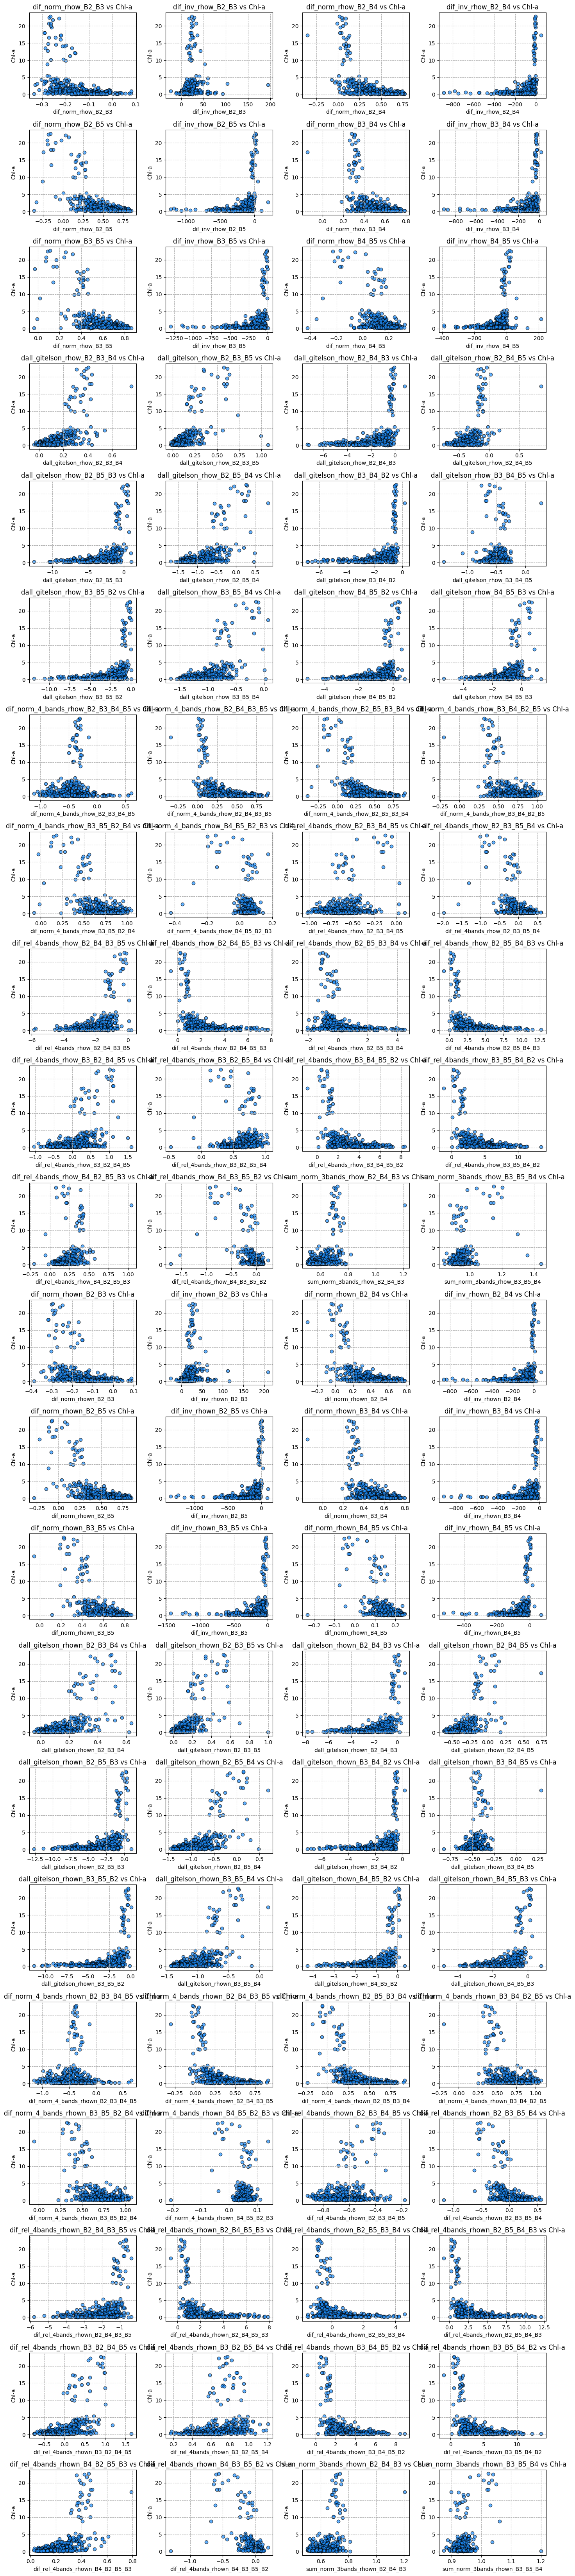

In [23]:
columns = df.columns[21:]#['UltraBlue', 'Blue', 'Green', 'Red', 'NIR1', 'NIR2', 'NIR3']
num_plots = len(columns)

num_cols = 4
num_rows = math.ceil(num_plots/num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 0.75*num_plots), sharex=False, sharey=False)

axes = axes.flatten()

for i, col in enumerate(columns):

    axes[i].scatter( df[col], df["Chl"], label=col, color="dodgerblue", alpha=0.7, edgecolor="k")
    
    axes[i].set_title(f'{col} vs Chl-a')
    axes[i].grid(linestyle='--')
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel(f'Chl-a')
    
fig.tight_layout()
plt.show()

In [35]:
abs(df.iloc[:,20:].corr()["Chl"]).sort_values()[-30:]

dif_rel_4bands_rhown_B2_B3_B5_B4      0.498806
dif_rel_4bands_rhown_B3_B2_B4_B5      0.501532
dif_norm_4_bands_rhow_B2_B4_B3_B5     0.511901
dif_norm_rhow_B3_B4                   0.514985
dif_norm_4_bands_rhown_B2_B4_B3_B5    0.519013
dif_norm_rhown_B3_B4                  0.525110
dif_norm_4_bands_rhown_B2_B5_B3_B4    0.549857
dif_norm_rhown_B4_B5                  0.555475
dif_norm_4_bands_rhow_B3_B5_B2_B4     0.555999
dif_norm_rhow_B2_B4                   0.557007
dif_rel_4bands_rhow_B4_B3_B5_B2       0.560477
dif_rel_4bands_rhown_B4_B2_B5_B3      0.563515
dif_norm_4_bands_rhow_B2_B5_B3_B4     0.564390
dif_norm_rhown_B2_B4                  0.569110
dall_gitelson_rhow_B2_B4_B5           0.570391
dall_gitelson_rhow_B3_B5_B4           0.575792
dif_rel_4bands_rhown_B4_B3_B5_B2      0.596582
dall_gitelson_rhow_B2_B5_B4           0.608223
dif_norm_rhown_B3_B5                  0.611007
dall_gitelson_rhow_B2_B3_B4           0.617505
dall_gitelson_rhown_B3_B5_B4          0.619683
dall_gitelson

In [36]:
abs(df.iloc[:,20:].corr(method='spearman')["Chl"]).sort_values()[-30:]

dif_rel_4bands_rhow_B3_B5_B4_B2       0.526214
dif_rel_4bands_rhown_B3_B5_B4_B2      0.527458
dall_gitelson_rhown_B2_B5_B4          0.532463
dall_gitelson_rhow_B2_B5_B3           0.534211
dall_gitelson_rhown_B2_B5_B3          0.538308
dall_gitelson_rhow_B3_B5_B2           0.545002
dall_gitelson_rhow_B2_B4_B3           0.545356
dall_gitelson_rhown_B2_B4_B3          0.548835
dif_norm_rhow_B2_B5                   0.549259
dif_rel_4bands_rhow_B2_B5_B4_B3       0.549520
dall_gitelson_rhown_B3_B5_B2          0.552517
dall_gitelson_rhown_B2_B3_B5          0.553169
dall_gitelson_rhow_B2_B3_B5           0.553529
dall_gitelson_rhown_B3_B4_B2          0.555683
dall_gitelson_rhow_B3_B4_B2           0.556024
dif_rel_4bands_rhown_B2_B5_B4_B3      0.556582
dall_gitelson_rhown_B2_B3_B4          0.557248
dif_norm_rhown_B2_B5                  0.558957
dif_norm_4_bands_rhow_B2_B5_B3_B4     0.561892
dif_rel_4bands_rhow_B2_B4_B5_B3       0.562942
dall_gitelson_rhown_B2_B4_B5          0.563138
dif_rel_4band

In [40]:
X = df.iloc[:,20:].loc[:, df.iloc[:,20:].columns != "Chl"]
y = df.iloc[:,20:].loc[:, "Chl"]
mi_scores = mutual_info_regression(X, y)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_df)

dif_norm_4_bands_rhow_B2_B4_B3_B5     0.364511
dif_norm_4_bands_rhown_B2_B5_B3_B4    0.361115
dif_norm_4_bands_rhown_B2_B4_B3_B5    0.336527
dall_gitelson_rhown_B2_B5_B3          0.334873
dall_gitelson_rhow_B2_B5_B3           0.334050
                                        ...   
dif_norm_4_bands_rhown_B3_B4_B2_B5    0.088511
dif_rel_4bands_rhown_B3_B2_B5_B4      0.088503
dall_gitelson_rhow_B3_B4_B5           0.088441
sum_norm_3bands_rhow_B3_B5_B4         0.083511
dif_rel_4bands_rhown_B2_B3_B4_B5      0.069056
Length: 88, dtype: float64


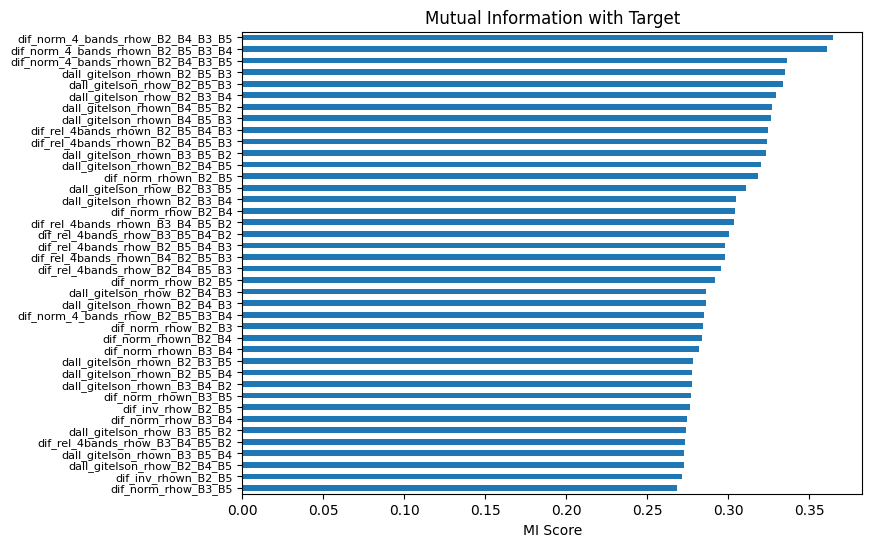

In [45]:
mi_df[mi_df>0.25].plot.barh(figsize=(8,6))
plt.title("Mutual Information with Target")
plt.xlabel("MI Score")
plt.gca().invert_yaxis()
plt.yticks(fontsize=8)
plt.show()

Text(0.5, 1.0, 'Matrix 1')

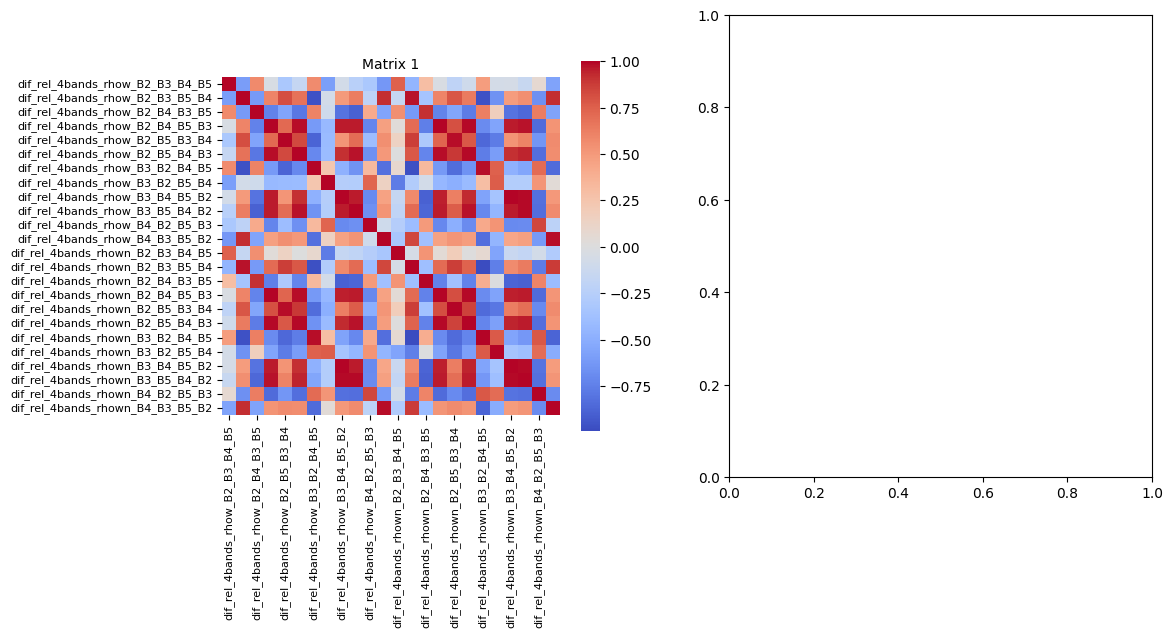

In [53]:
df_filtered_1 = df[[col for col in df.columns if col.startswith("dif_rel_4bands")]]
corr1 = df_filtered_1.corr().round(2).astype(float)
mask1 = np.triu(np.ones_like(corr1, dtype=bool))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Heatmap 1
sns.heatmap(corr1,
            #mask=mask1,
            square=True, cmap='coolwarm', annot=False, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].tick_params(axis='both', labelsize=8)
axes[0].set_title("Matrix 1", fontsize=10)

# # Heatmap 2
# to_drop_1 = ["index_dg_UltraBlue_Green_Red", "index_dg_UltraBlue_Blue_NIR1", "index_dg_Green_UltraBlue_Red", "index_dg_Green_UltraBlue_Blue", "index_dg_Green_UltraBlue_NIR1", "index_dg_Green_Blue_Red"]
# corr2 = df_filtered_1.drop(columns=to_drop_1).corr().round(2).astype(float)
# sns.heatmap(corr2,
#             #mask=mask1,
#             square=True, cmap='coolwarm', annot=False, ax=axes[1], cbar_kws={"shrink": .8})
# axes[1].tick_params(axis='both', labelsize=8)
# axes[1].set_title("Matrix 2", fontsize=10)

# plt.tight_layout()
# plt.show()


In [68]:
df = dfs["C2X-Complex_3x3_merge_depth_lt_1"].iloc[:,20:]

In [69]:
# Calcular correlaciones con 'Chl'
correlaciones = df.corr(numeric_only=True)['Chl'].drop('Chl')

# Filtrar por umbral
umbral_corr = 0.25
predictores_utiles = correlaciones[correlaciones.abs() >= umbral_corr].index
df_filtrado = df[predictores_utiles.tolist() + ['Chl']]


In [70]:
# Calcular la matriz de correlación entre predictores
corr_matrix = df_filtrado.drop(columns='Chl').corr().abs()

# Seleccionar columnas a eliminar (altamente correlacionadas entre sí)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
columnas_redundantes = [col for col in upper.columns if any(upper[col] > 0.95)]

# Eliminar redundantes
df_final = df_filtrado.drop(columns=columnas_redundantes)


In [71]:
columnas_redundantes

['dif_inv_rhow_B2_B5',
 'dif_norm_rhow_B3_B4',
 'dif_inv_rhow_B3_B4',
 'dif_norm_rhow_B3_B5',
 'dif_inv_rhow_B3_B5',
 'dall_gitelson_rhow_B2_B5_B3',
 'dall_gitelson_rhow_B2_B5_B4',
 'dall_gitelson_rhow_B3_B4_B2',
 'dall_gitelson_rhow_B3_B5_B2',
 'dall_gitelson_rhow_B3_B5_B4',
 'dall_gitelson_rhow_B4_B5_B3',
 'dif_norm_4_bands_rhow_B2_B4_B3_B5',
 'dif_norm_4_bands_rhow_B2_B5_B3_B4',
 'dif_norm_4_bands_rhow_B3_B5_B2_B4',
 'dif_rel_4bands_rhow_B2_B4_B5_B3',
 'dif_rel_4bands_rhow_B2_B5_B4_B3',
 'dif_rel_4bands_rhow_B3_B2_B4_B5',
 'dif_rel_4bands_rhow_B3_B4_B5_B2',
 'dif_rel_4bands_rhow_B3_B5_B4_B2',
 'sum_norm_3bands_rhow_B2_B4_B3',
 'sum_norm_3bands_rhow_B3_B5_B4',
 'dif_norm_rhown_B2_B3',
 'dif_norm_rhown_B2_B4',
 'dif_inv_rhown_B2_B4',
 'dif_norm_rhown_B2_B5',
 'dif_inv_rhown_B2_B5',
 'dif_norm_rhown_B3_B4',
 'dif_inv_rhown_B3_B4',
 'dif_norm_rhown_B3_B5',
 'dif_inv_rhown_B3_B5',
 'dif_inv_rhown_B4_B5',
 'dall_gitelson_rhown_B2_B3_B4',
 'dall_gitelson_rhown_B2_B3_B5',
 'dall_gitelson_rh

In [72]:
df_final

,dif_norm_rhow_B2_B3,dif_norm_rhow_B2_B4,dif_inv_rhow_B2_B4,dif_norm_rhow_B2_B5,dif_norm_rhow_B4_B5,dif_inv_rhow_B4_B5,dall_gitelson_rhow_B2_B3_B4,dall_gitelson_rhow_B2_B3_B5,dall_gitelson_rhow_B2_B4_B3,dall_gitelson_rhow_B2_B4_B5,...,dif_rel_4bands_rhow_B2_B5_B3_B4,dif_rel_4bands_rhow_B4_B2_B5_B3,dif_rel_4bands_rhow_B4_B3_B5_B2,dif_norm_rhown_B4_B5,dall_gitelson_rhown_B2_B4_B5,dall_gitelson_rhown_B3_B4_B5,dif_rel_4bands_rhown_B2_B3_B4_B5,dif_rel_4bands_rhown_B2_B4_B3_B5,sum_norm_3bands_rhown_B3_B5_B4,Chl
0,-0.263,0.064,-7.859,0.123,0.060,-8.324,0.367,0.326,-0.233,-0.106,...,-0.667,0.425,-0.268,0.089,-0.086,-0.409,-0.625,-1.223,0.945,10.0900
1,-0.181,0.109,-16.387,0.192,0.084,-15.334,0.246,0.208,-0.354,-0.166,...,-0.320,0.333,-0.121,0.077,-0.177,-0.381,-0.467,-0.841,0.949,11.2050
2,-0.158,0.098,-13.565,0.270,0.177,-32.609,0.224,0.157,-0.299,-0.125,...,0.066,0.404,0.023,0.160,-0.131,-0.285,-0.642,-1.060,0.896,12.0750
3,-0.277,0.051,-12.875,-0.258,-0.305,62.398,0.392,0.735,-0.188,-0.181,...,-1.365,-0.057,-1.184,-0.076,0.096,-0.491,-0.323,-0.558,1.061,8.8400
4,-0.161,0.140,-21.394,0.277,0.143,-29.043,0.210,0.157,-0.451,-0.184,...,-0.068,0.346,-0.021,0.128,-0.199,-0.351,-0.558,-1.022,0.920,12.1500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,-0.080,0.583,-85.947,0.714,0.225,-67.842,0.039,0.025,-3.279,-0.466,...,1.545,0.122,0.058,0.235,-0.448,-0.476,-0.778,-3.353,0.928,0.2805
447,-0.159,0.277,-32.422,0.445,0.192,-35.542,0.156,0.106,-1.054,-0.294,...,0.170,0.288,0.027,0.185,-0.294,-0.400,-0.726,-1.737,0.908,0.4625
448,-0.135,0.518,-102.619,0.635,0.175,-64.012,0.076,0.053,-2.816,-0.479,...,0.358,0.148,0.019,0.186,-0.458,-0.515,-0.709,-2.849,0.937,0.6735
449,-0.146,0.503,-101.924,0.590,0.124,-43.153,0.084,0.066,-2.719,-0.522,...,-0.179,0.139,-0.011,0.173,-0.466,-0.529,-0.681,-2.726,0.941,0.4145
